In [59]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import f_classif,chi2
from sklearn.model_selection import train_test_split




In [ ]:
df=pd.read_csv("titanic.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df['Age']=df['Age'].fillna(df['Age'].median())

In [ ]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

In [ ]:
df['Cabin']=df['Cabin'].fillna("No Cabin")

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,No Cabin,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,No Cabin,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,No Cabin,S


In [ ]:
encoder=LabelEncoder()
df['Gender']=encoder.fit_transform(df['Sex'])

In [ ]:
df.drop(['PassengerId','Name','Ticket','Sex'],axis=1,inplace=True)

In [ ]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin,Embarked,Gender
0,0,3,22.0,1,0,7.2500,No Cabin,S,1
1,1,1,38.0,1,0,71.2833,C85,C,0
2,1,3,26.0,0,0,7.9250,No Cabin,S,0
3,1,1,35.0,1,0,53.1000,C123,S,0
4,0,3,35.0,0,0,8.0500,No Cabin,S,1


In [ ]:
df=pd.get_dummies(df,columns=['Embarked'],drop_first=True)
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin,Gender,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,No Cabin,1,False,True
1,1,1,38.0,1,0,71.2833,C85,0,False,False
2,1,3,26.0,0,0,7.9250,No Cabin,0,False,True
3,1,1,35.0,1,0,53.1000,C123,0,False,True
4,0,3,35.0,0,0,8.0500,No Cabin,1,False,True


In [ ]:
df['Cabin'].value_counts()

,count
Cabin,
No Cabin,687
G6,4
C23 C25 C27,4
B96 B98,4
F2,3
...,...
E17,1
A24,1
C50,1


In [ ]:
df.loc[df['Cabin']!='No Cabin','Cabin']='Cabin'

In [ ]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin,Gender,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,No Cabin,1,False,True
1,1,1,38.0,1,0,71.2833,Cabin,0,False,False
2,1,3,26.0,0,0,7.9250,No Cabin,0,False,True
3,1,1,35.0,1,0,53.1000,Cabin,0,False,True
4,0,3,35.0,0,0,8.0500,No Cabin,1,False,True


In [ ]:
encoder=LabelEncoder()

In [ ]:
df['Cabin']=encoder.fit_transform(df['Cabin'])

In [ ]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin,Gender,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,1,1,False,True
1,1,1,38.0,1,0,71.2833,0,0,False,False
2,1,3,26.0,0,0,7.9250,1,0,False,True
3,1,1,35.0,1,0,53.1000,0,0,False,True
4,0,3,35.0,0,0,8.0500,1,1,False,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Cabin       891 non-null    int64  
 7   Gender      891 non-null    int64  
 8   Embarked_Q  891 non-null    bool   
 9   Embarked_S  891 non-null    bool   
dtypes: bool(2), float64(2), int64(6)
memory usage: 57.6 KB


In [28]:
X=df.drop("Survived",axis=1)
y=df['Survived']

In [29]:
X.head()

,Pclass,Age,SibSp,Parch,Fare,Cabin,Gender,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,1,1,False,True
1,1,38.0,1,0,71.2833,0,0,False,False
2,3,26.0,0,0,7.9250,1,0,False,True
3,1,35.0,1,0,53.1000,0,0,False,True
4,3,35.0,0,0,8.0500,1,1,False,True


In [30]:
y.head()

,Survived
0,0
1,1
2,1
3,1
4,0


In [31]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [32]:
X_train

,Pclass,Age,SibSp,Parch,Fare,Cabin,Gender,Embarked_Q,Embarked_S
331,1,45.5,0,0,28.5000,0,1,False,True
733,2,23.0,0,0,13.0000,1,1,False,True
382,3,32.0,0,0,7.9250,1,1,False,True
704,3,26.0,1,0,7.8542,1,1,False,True
813,3,6.0,4,2,31.2750,1,0,False,True
...,...,...,...,...,...,...,...,...,...
106,3,21.0,0,0,7.6500,1,0,False,True
270,1,28.0,0,0,31.0000,1,1,False,True
860,3,41.0,2,0,14.1083,1,1,False,True
435,1,14.0,1,2,120.0000,0,0,False,True


In [33]:
y_train

,Survived
331,0
733,0
382,0
704,0
813,0
...,...
106,1
270,0
860,0
435,1


In [40]:
numerical_cols=X_train[['Age','Fare']]
pearson_corr=numerical_cols.corr(method='pearson')

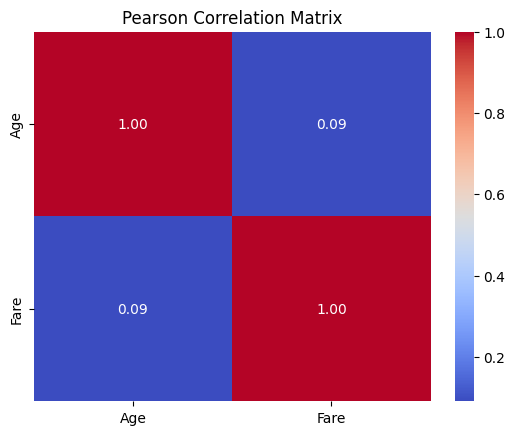

In [41]:
sns.heatmap(pearson_corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Pearson Correlation Matrix")
plt.show()

In [42]:
spearman_corr=numerical_cols.corr(method='spearman')

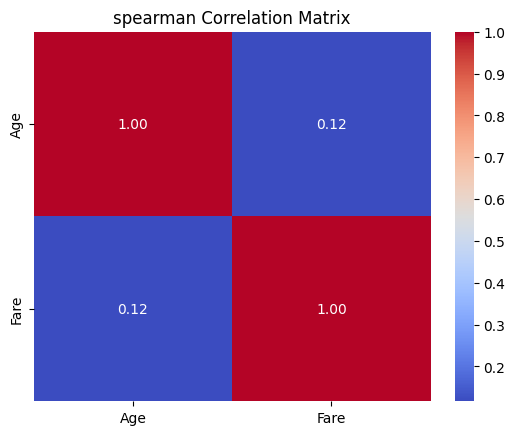

In [43]:
sns.heatmap(spearman_corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("spearman Correlation Matrix")
plt.show()

In [47]:
anova_scores,anova_pvalues=f_classif(numerical_cols,y_train)

In [52]:
anova_results=pd.DataFrame({
    'Feature':numerical_cols.columns,
    "Anova_score":anova_scores,
    "p_value":anova_pvalues
})

In [53]:
anova_results.sort_values("p_value",ascending=False)

,Feature,Anova_score,p_value
0,Age,1.680118,1.953299e-01
1,Fare,45.988025,2.506434e-11


In [54]:
cat_cols=X_train[['Pclass','Cabin','Gender']]

In [55]:
cat_cols

,Pclass,Cabin,Gender
331,1,0,1
733,2,1,1
382,3,1,1
704,3,1,1
813,3,1,0
...,...,...,...
106,3,1,0
270,1,1,1
860,3,1,1
435,1,0,0


In [56]:
chi_scores,p_value=chi2(cat_cols,y_train)

In [57]:
chi_results=pd.DataFrame({
    "Feature":cat_cols.columns,
    "Chi2_Score":chi_scores,
    "P_Value":p_value
})

In [58]:
chi_results.sort_values("P_Value",ascending=False)


,Feature,Chi2_Score,P_Value
1,Cabin,14.345399,1.521511e-04
0,Pclass,21.478863,3.577504e-06
2,Gender,71.905882,2.257101e-17


Apply the previous steps on : UCI Adult Income Dataset